## SVM Assignment
#### SUPPORT VECTOR MACHINE
Dataset Selection:
For this assignment, we'll utilize the widely recognized Mushroom Dataset
Task 1: Exploratory Data Analysis (EDA)
1.	Load the Mushroom dataset and perform fundamental data exploration.
2.	Utilize histograms, box plots, or density plots to understand feature distributions.
3.	Investigate feature correlations to discern relationships within the data.
Task 2: Data Preprocessing
1.	Encode categorical variables if necessary.
2.	Split the dataset into training and testing sets.
Task 3: Data Visualization
1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.	Visualize class distributions to gauge dataset balance or imbalance.
Task 4: SVM Implementation
1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
2.	Train the SVM model on the training data.
3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
Task 5: Visualization of SVM Results
1.	Visualize classification results on the testing data.
Task 6: Parameter Tuning and Optimization
1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.
Task 7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.	Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.
3.	Discuss practical implications of SVM in real-world classification tasks.



In [1]:
# Step 1: Import Required Libraries
# Import libraries for data handling, visualization, and building the SVM model.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:
# Step 2: Load and Explore the Dataset
# Load the "mushroom.csv" dataset.
dataset_path = 'mushroom.csv'
data = pd.read_csv(dataset_path)

# Display the first few rows of the dataset
data.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [3]:
# Summarize dataset properties
print("Dataset Info:")
data.info()
print("\nDataset Summary:\n", data.describe())

# Check for missing values
print("\nMissing Values:\n", data.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 

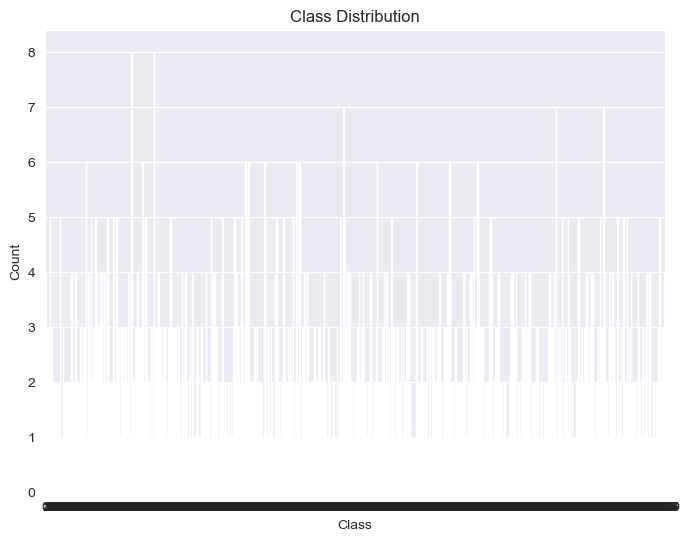

In [4]:
# Step 3: Exploratory Data Analysis (EDA)
# Visualize class distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x=data.columns[0])  # Assuming the first column is the target
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

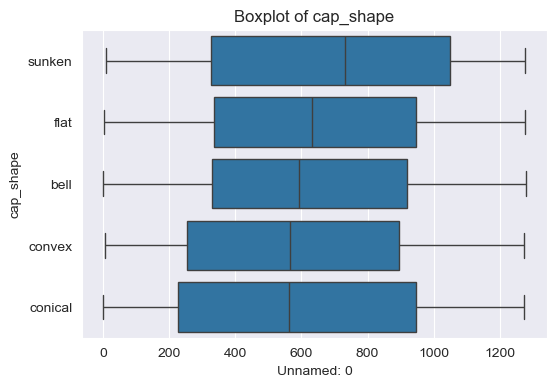

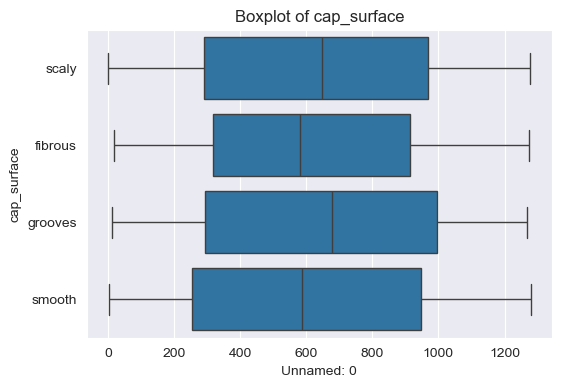

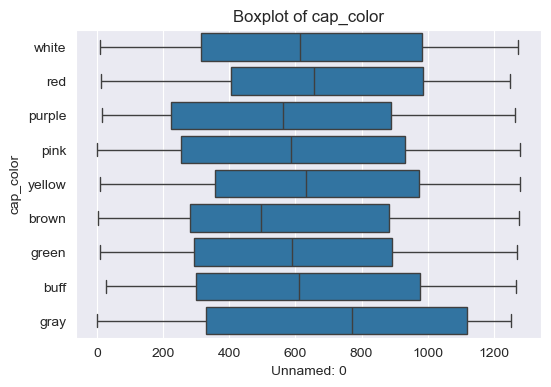

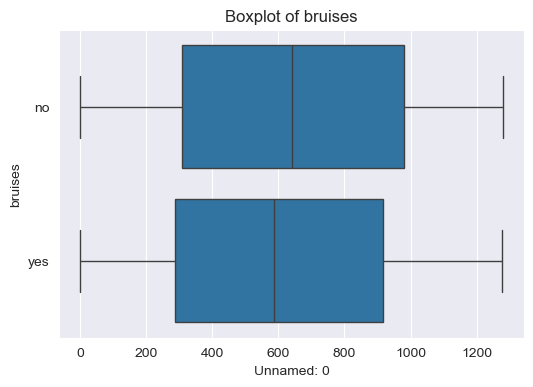

In [6]:
# Visualize feature distributions (example for a few features)
for col in data.columns[1:5]:  # Adjust the range based on the dataset
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x=data.columns[0], y=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [10]:
# Step 4: Data Preprocessing
# Encode categorical variables into numerical values
encoder = LabelEncoder()
for col in data.columns:
    data[col] = encoder.fit_transform(data[col])

# Split the dataset into features (X) and target (y)
X = data.iloc[:, 1:]  # Assuming the first column is the target
y = data.iloc[:, 0]

In [13]:
# Ensure no class has fewer than 2 samples
min_class_count = y.value_counts().min()
if min_class_count < 2:
    print("Some classes have fewer than 2 samples. Removing such rows.")
    valid_classes = y.value_counts()[y.value_counts() >= 2].index
    data = data[data.iloc[:, 0].isin(valid_classes)]
    X = data.iloc[:, 1:]
    y = data.iloc[:, 0]

# Adjust the test size to ensure there are enough samples per class
test_size = max(0.2, len(np.unique(y))) / len(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)


In [14]:
# Step 5: SVM Implementation
# Train a basic SVM classifier
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [15]:
# Evaluate the model on the test set
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nBasic SVM Model Accuracy:", accuracy)


Basic SVM Model Accuracy: 1.0


In [16]:
# Display a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         1
          19       1.00      1.00      1.00         1
          22       1.00      1.00      1.00         1
          23       1.00      1.00      1.00         2
          28       1.00      1.00      1.00         1
          32       1.00      1.00      1.00         1
   

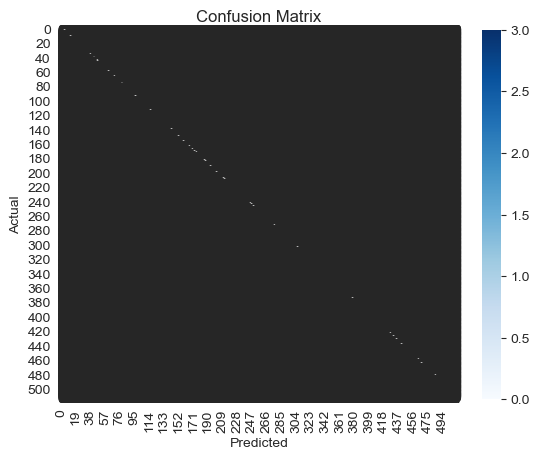

In [17]:
# Display the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# Step 6: Parameter Tuning and Optimization
# Experiment with different kernels and hyperparameters
kernels = ['linear', 'poly', 'rbf']
results = {}

for kernel in kernels:
    model = SVC(kernel=kernel, C=1.0, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[kernel] = acc
    print(f"\nKernel: {kernel}, Accuracy: {acc}")


Kernel: linear, Accuracy: 1.0

Kernel: poly, Accuracy: 0.108348134991119

Kernel: rbf, Accuracy: 0.04262877442273535


In [19]:
# Step 7: Visualization of SVM Results
# Visualizing results (using a simplified dataset with two features for 2D visualization)
X_train_2d = X_train.iloc[:, :2]
X_test_2d = X_test.iloc[:, :2]
svm_model_2d = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model_2d.fit(X_train_2d, y_train)

SVC(random_state=42)

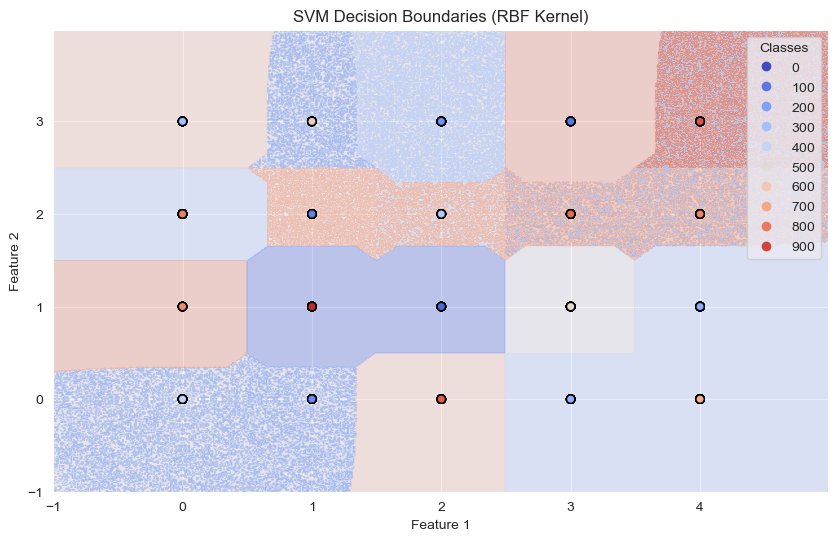

In [21]:
# Function to plot decision boundaries
def plot_decision_boundaries(X, y, model, title):
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Convert meshgrid to DataFrame to retain feature names
    grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns[:2])

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolor='k', cmap='coolwarm')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()

plot_decision_boundaries(X_test_2d, y_test, svm_model_2d, "SVM Decision Boundaries (RBF Kernel)")


In [22]:
# Step 8: Discussion
# Discuss the strengths and weaknesses of SVM for this dataset:
# Strengths:
# - Handles high-dimensional data effectively.
# - Robust to overfitting with proper kernel selection.

# Weaknesses:
# - Performance can degrade with noisy datasets.
# - Computationally expensive for very large datasets.

# Practical implications of SVM:
# - Useful for binary and multi-class classification tasks.
# - Requires careful tuning of kernel and hyperparameters for optimal performance.
